In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
# from PIL import Image

# # -----------------------------
# # Load image
# # -----------------------------
# img = Image.open("P:\\Downloads\\data2.jpg").convert("RGB")
# img = img.resize((200, 200))  # ← critical

# arr = np.array(img)

# H, W, _ = arr.shape
# X = arr.reshape(-1, 3).astype(np.float32) / 255.0


# # Normalize (important for distance-based clustering)
# X = X / 255.0


# # ======================================================
# # 1️⃣ K-MEANS (k = 2)
# # ======================================================
# kmeans = KMeans(n_clusters=2, random_state=0, n_init=10)
# labels_km = kmeans.fit_predict(X)

# seg_km = labels_km.reshape(H, W)


# # ======================================================
# # 2️⃣ AGGLOMERATIVE HIERARCHICAL (k = 2)
# # ======================================================
# agg = AgglomerativeClustering(n_clusters=2, linkage="ward")
# labels_agg = agg.fit_predict(X)

# seg_agg = labels_agg.reshape(H, W)


# # ======================================================
# # 3️⃣ DBSCAN
# # (no fixed k, tune eps to roughly get 2 regions)
# # ======================================================
# db = DBSCAN(eps=0.05, min_samples=50)
# labels_db = db.fit_predict(X)

# # Convert noise (-1) to new label
# labels_db[labels_db == -1] = labels_db.max() + 1

# seg_db = labels_db.reshape(H, W)


# # ======================================================
# # Visualization
# # ======================================================
# plt.figure(figsize=(12, 4))

# plt.subplot(1, 4, 1)
# plt.imshow(arr)
# plt.title("Original")
# plt.axis("off")

# plt.subplot(1, 4, 2)
# plt.imshow(seg_km, cmap="gray")
# plt.title("KMeans")
# plt.axis("off")

# plt.subplot(1, 4, 3)
# plt.imshow(seg_agg, cmap="gray")
# plt.title("Agglomerative")
# plt.axis("off")

# plt.subplot(1, 4, 4)
# plt.imshow(seg_db, cmap="gray")
# plt.title("DBSCAN")
# plt.axis("off")

# plt.tight_layout()
# plt.show()

In [1]:
import numpy as np
from PIL import Image

# load image
img = Image.open("P:\\Downloads\\data2.jpg")

# convert to numpy array
img_arr = np.array(img)  # shape: (H, W, 3)

# reshape (flatten spatial dimensions)
pixels = img_arr.reshape(-1, 3)

print(pixels.shape)

(921600, 3)


In [ ]:
# import numpy as np
# import cv2
# import matplotlib.pyplot as plt
# from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
# from sklearn.preprocessing import StandardScaler

# # -------------------------
# # 1. Load image
# # -------------------------
# img = cv2.imread("P:\\Downloads\\data2.jpg")


# img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# H, W, C = img.shape

# # flatten pixels -> (n_samples, 3)
# pixels = img.reshape(-1, 3).astype(float)


# # optional but recommended for clustering
# scaler = StandardScaler()
# pixels_scaled = scaler.fit_transform(pixels)


# # -------------------------
# # 2. KMEANS (k=2)
# # -------------------------
# kmeans = KMeans(n_clusters=2, random_state=0, n_init=10)
# labels_km = kmeans.fit_predict(pixels_scaled)


# # -------------------------
# # 3. Agglomerative (k=2)
# # -------------------------
# agg = AgglomerativeClustering(n_clusters=2, linkage="ward")
# labels_agg = agg.fit_predict(pixels_scaled)


# # -------------------------
# # 4. DBSCAN
# # (eps may need tuning)
# # -------------------------
# db = DBSCAN(eps=0.6, min_samples=20)
# labels_db = db.fit_predict(pixels_scaled)

# # DBSCAN may produce -1 (noise)
# labels_db[labels_db == -1] = 0


# # -------------------------
# # 5. Convert labels -> images
# # -------------------------
# def labels_to_image(labels):
#     return labels.reshape(H, W)


# img_km = labels_to_image(labels_km)
# img_agg = labels_to_image(labels_agg)
# img_db = labels_to_image(labels_db)


# # -------------------------
# # 6. Visualize
# # -------------------------
# plt.figure(figsize=(10, 6))

# plt.subplot(221)
# plt.imshow(img)
# plt.title("Original")
# plt.axis("off")

# plt.subplot(222)
# plt.imshow(img_km)
# plt.title("KMeans")
# plt.axis("off")

# plt.subplot(223)
# plt.imshow(img_agg)
# plt.title("Agglomerative")
# plt.axis("off")

# plt.subplot(224)
# plt.imshow(img_db)
# plt.title("DBSCAN")
# plt.axis("off")

# plt.tight_layout()
# plt.show()

MemoryError: Unable to allocate 3.09 TiB for an array with shape (424672819200,) and data type float64

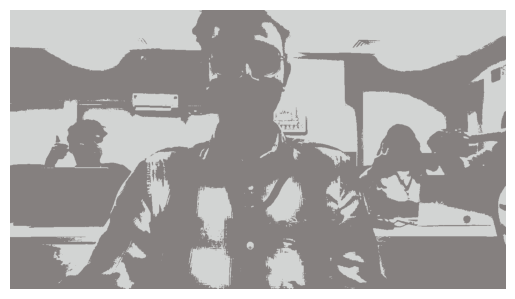

In [6]:
import numpy as np
import cv2
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Read image
img = cv2.imread("P:\\Downloads\\data2.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w, c = img.shape

# 2. Flatten pixels → (n_pixels, 3)
pixels = img.reshape(-1, 3)

# 3. Normalize (important for ML stability)
pixels = pixels / 255.0

# 4. KMeans clustering
kmeans = KMeans(n_clusters=2, random_state=0, n_init=10)
labels = kmeans.fit_predict(pixels)

# 5. Replace each pixel with its cluster center color
segmented = kmeans.cluster_centers_[labels]

# 6. Reshape back to image
segmented_img = segmented.reshape(h, w, 3)

# 7. Show result
plt.imshow(segmented_img)
plt.axis("off")
plt.show()

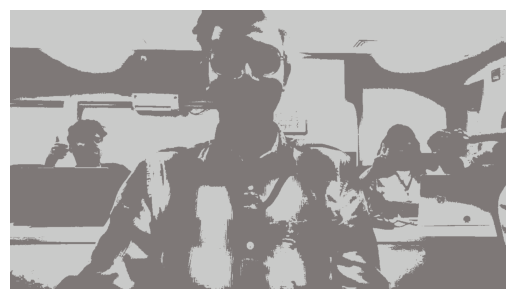

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from sklearn.neighbors import NearestCentroid

# 1. Read image
img = cv2.imread("P:\\Downloads\\data2.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w, c = img.shape

# 2. Flatten
pixels = img.reshape(-1, 3).astype(np.float32) / 255.0

# ---------------------------
# MEMORY SAFE SAMPLING
# ---------------------------
sample_size = 8000
idx = np.random.choice(len(pixels), sample_size, replace=False)
sample = pixels[idx]

# 3. Agglomerative clustering on sample only
agg = AgglomerativeClustering(n_clusters=2, linkage="ward")
sample_labels = agg.fit_predict(sample)

# 4. Compute centroids
clf = NearestCentroid()
clf.fit(sample, sample_labels)

# 5. Predict labels for ALL pixels
labels = clf.predict(pixels)

# 6. Replace with cluster centers
segmented = clf.centroids_[labels]

segmented_img = segmented.reshape(h, w, 3)

# 7. Show
plt.imshow(segmented_img)
plt.axis("off")
plt.show()

Clusters found: 1


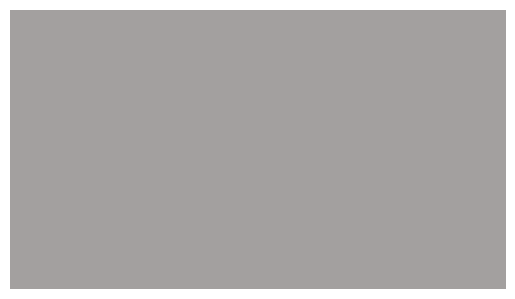

In [ ]:
# import numpy as np
# import cv2
# import matplotlib.pyplot as plt
# from sklearn.cluster import DBSCAN
# from sklearn.metrics import pairwise_distances_argmin

# # 1. Load image
# img = cv2.imread("P:\\Downloads\\data2.jpg")
# img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# h, w, _ = img.shape

# # 2. Flatten (each pixel = feature vector [R,G,B])
# pixels = img.reshape(-1, 3).astype(np.float32) / 255.0


# # -------------------------
# # RAM SAFE SAMPLING
# # -------------------------
# max_samples = 8000

# idx = np.random.choice(len(pixels), max_samples, replace=False)
# sample_pixels = pixels[idx]


# # -------------------------
# # DBSCAN
# # -------------------------
# db = DBSCAN(eps=0.08, min_samples=20, n_jobs=-1)  # tune this  # faster

# sample_labels = db.fit_predict(sample_pixels)


# # -------------------------
# # Remove noise (-1 labels)
# # -------------------------
# valid_mask = sample_labels != -1
# sample_pixels = sample_pixels[valid_mask]
# sample_labels = sample_labels[valid_mask]


# # -------------------------
# # Compute cluster centers manually
# # -------------------------
# centers = np.array(
#     [sample_pixels[sample_labels == i].mean(axis=0) for i in np.unique(sample_labels)]
# )


# print("Clusters found:", len(centers))


# # -------------------------
# # Assign ALL pixels to nearest center
# # -------------------------
# labels_all = pairwise_distances_argmin(pixels, centers)

# segmented = centers[labels_all]

# segmented_img = segmented.reshape(h, w, 3)


# # -------------------------
# # Show result
# # -------------------------
# plt.imshow(segmented_img)
# plt.axis("off")
# plt.show()

Clusters found: 4


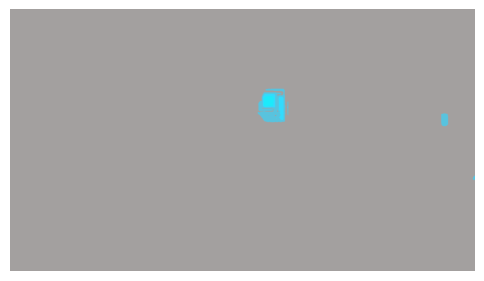

In [9]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.metrics import pairwise_distances_argmin

# =========================
# 1. Load image
# =========================
img = cv2.imread("P:\\Downloads\\data2.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w, _ = img.shape

# pixel -> feature vector [R,G,B]
pixels = img.reshape(-1, 3).astype(np.float32) / 255.0


# =========================
# 2. Larger sampling (Colab safe)
# =========================
max_samples = 30000  # works fine in Colab

if len(pixels) > max_samples:
    idx = np.random.choice(len(pixels), max_samples, replace=False)
    sample_pixels = pixels[idx]
else:
    sample_pixels = pixels


# =========================
# 3. DBSCAN
# =========================
eps_value = 0.06  # <<< tune this

db = DBSCAN(eps=eps_value, min_samples=15, n_jobs=-1)

labels = db.fit_predict(sample_pixels)


# =========================
# 4. Remove noise (-1)
# =========================
mask = labels != -1
sample_pixels = sample_pixels[mask]
labels = labels[mask]


# =========================
# 5. Compute cluster centers
# =========================
unique_labels = np.unique(labels)

centers = np.array([sample_pixels[labels == k].mean(axis=0) for k in unique_labels])

print("Clusters found:", len(centers))


# =========================
# 6. Assign all pixels
# =========================
labels_all = pairwise_distances_argmin(pixels, centers)
segmented = centers[labels_all]

segmented_img = segmented.reshape(h, w, 3)


# =========================
# 7. Show
# =========================
plt.figure(figsize=(6, 6))
plt.imshow(segmented_img)
plt.axis("off")
plt.show()